In [3]:
!pip install seaborn


[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: C:\Users\lenovo\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [3]:
import seaborn as sns
print(sns.__version__)

0.13.2


In [8]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1️⃣ Paths - update if needed
zip_path = r'D:\Euphoscan\data\HAM10000_images_part_1.zip'
extract_dir = r'D:\Euphoscan\data\HAM10000_images_part_1'
csv_file = r'D:\Euphoscan\data\metadata.csv'
model_base_dir = r'D:\Euphoscan\model'  # Folder containing model files

# 2️⃣ Unzip dataset if not already done
if not os.path.exists(extract_dir):
    print("Extracting images from ZIP...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
else:
    print("Images already extracted.")

# 3️⃣ Load CSV and prepare class folders
df = pd.read_csv(csv_file)
df['dx'] = df['dx'].astype(str)

for cls in df['dx'].unique():
    os.makedirs(os.path.join(extract_dir, cls), exist_ok=True)

print("Moving images to class folders...")
for _, row in df.iterrows():
    img = row['image_id'] + '.jpg'
    label = row['dx']
    src = os.path.join(extract_dir, img)
    dst = os.path.join(extract_dir, label, img)
    if os.path.exists(src) and not os.path.exists(dst):
        os.rename(src, dst)

# 4️⃣ Prepare ImageDataGenerator for evaluation
datagen = ImageDataGenerator(rescale=1./255)
val_generator = datagen.flow_from_directory(
    extract_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

# 5️⃣ Check model files present
print("Model directory contents:")
files = os.listdir(model_base_dir)
print(files)

# 6️⃣ Specify model names (change if needed)
model_folder_name = 'euphoscan_model'    # for SavedModel folder (no extension)
model_h5_filename = 'euphoscan_model.h5' # for .h5 file

model_folder_path = os.path.join(model_base_dir, model_folder_name)
model_h5_path = os.path.join(model_base_dir, model_h5_filename)

model = None

# 7️⃣ Try loading SavedModel folder first
if os.path.exists(model_folder_path):
    print(f"Trying to load model from SavedModel folder: {model_folder_path}")
    try:
        model = tf.keras.models.load_model(model_folder_path)
        print("Model loaded successfully from folder.")
    except Exception as e:
        print(f"Failed to load model from folder: {e}")

# 8️⃣ If folder load failed or doesn't exist, try loading .h5 file
if model is None and os.path.exists(model_h5_path):
    print(f"Trying to load model from .h5 file: {model_h5_path}")
    try:
        model = tf.keras.models.load_model(model_h5_path)
        print("Model loaded successfully from .h5 file.")
    except Exception as e:
        print(f"Failed to load model from .h5 file: {e}")

# 9️⃣ If no model loaded, print error and exit
if model is None:
    print("ERROR: No valid model loaded. Please check your model files.")
else:
    # 10️⃣ Run prediction and evaluation
    steps = val_generator.samples // val_generator.batch_size + 1
    print("Predicting on validation data...")
    preds = model.predict(val_generator, steps=steps)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_generator.classes
    class_labels = list(val_generator.class_indices.keys())

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()


Images already extracted.
Moving images to class folders...


Found 5000 images belonging to 7 classes.
Model directory contents:
['euphoscan_model.h5', 'euphoscan_model.tflite']
Trying to load model from .h5 file: D:\Euphoscan\model\euphoscan_model.h5
Failed to load model from .h5 file: Unable to synchronously open file (file signature not found)
ERROR: No valid model loaded. Please check your model files.


Found 4002 images belonging to 7 classes.
Found 998 images belonging to 7 classes.


c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       401,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,015 (1.55 MB)

...

 Non-trainable params: 0 (0.00 B)

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.6462 - loss: 1.1559 - val_accuracy: 0.6884 - val_loss: 0.9903
Epoch 2/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 131s 1s/step - accuracy: 0.6958 - loss: 0.9452 - val_accuracy: 0.6954 - val_loss: 0.8732
Epoch 3/3
126/126 ━━━━━━━━━━━━━━━━━━━━ 122s 961ms/step - accuracy: 0.7035 - loss: 0.8580 - val_accuracy: 0.7014 - val_loss: 0.8366


Model saved at D:\Euphoscan\model\euphoscan_model.h5
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 650ms/step

Classification Report:
              precision    recall  f1-score   support

       akiec       0.00      0.00      0.00        36
         bcc       0.00      0.00      0.00        53
         bkl       0.33      0.61      0.42       112
          df       0.00      0.00      0.00        11
         mel       0.28      0.06      0.10        87
          nv       0.81      0.91      0.86       686
        vasc       0.00      0.00      0.00        13

    accuracy                           0.70       998
   macro avg       0.20      0.23      0.20       998
weighted avg       0.62      0.70      0.65       998



c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

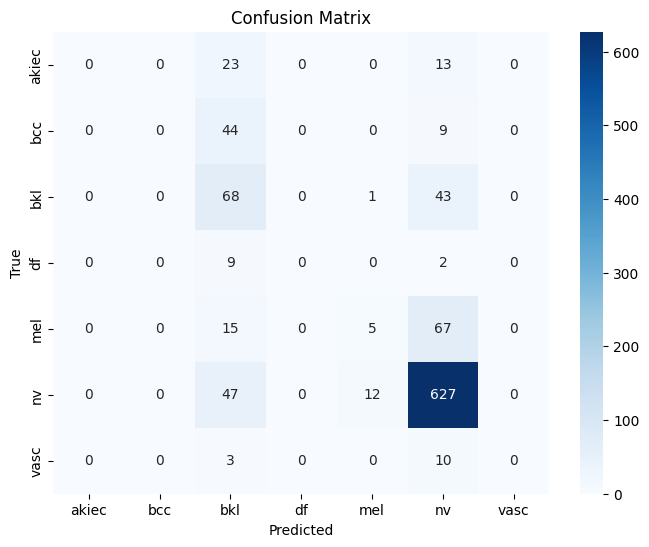

In [11]:
import os
import zipfile
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
zip_path = r'D:\Euphoscan\data\HAM10000_images_part_1.zip'
extract_dir = r'D:\Euphoscan\data\HAM10000_images_part_1'
csv_file = r'D:\Euphoscan\data\metadata.csv'
model_save_path = r'D:\Euphoscan\model\euphoscan_model.h5'

# Unzip if needed
if not os.path.exists(extract_dir):
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)

# Prepare folders and move images
df = pd.read_csv(csv_file)
df['dx'] = df['dx'].astype(str)
for cls in df['dx'].unique():
    os.makedirs(os.path.join(extract_dir, cls), exist_ok=True)

for _, row in df.iterrows():
    img = row['image_id'] + '.jpg'
    label = row['dx']
    src = os.path.join(extract_dir, img)
    dst = os.path.join(extract_dir, label, img)
    if os.path.exists(src) and not os.path.exists(dst):
        os.rename(src, dst)

# Data generators with validation split
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_generator = datagen.flow_from_directory(
    extract_dir,
    target_size=(64, 64),  # smaller size for speed
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_generator = datagen.flow_from_directory(
    extract_dir,
    target_size=(64, 64),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

num_classes = len(train_generator.class_indices)

# Minimal CNN model
model = Sequential([
    Conv2D(16, (3,3), activation='relu', input_shape=(64,64,3)),
    MaxPooling2D(2,2),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model.compile(optimizer=Adam(), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

# Train for just 3 epochs to save time
model.fit(train_generator, validation_data=val_generator, epochs=3)

# Save model
model.save(model_save_path)
print(f"Model saved at {model_save_path}")

# Evaluate
steps = val_generator.samples // val_generator.batch_size + 1
preds = model.predict(val_generator, steps=steps)
y_pred = np.argmax(preds, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_labels))

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_labels, yticklabels=class_labels, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()
